# Car Price Prediction

- **Problem Type**: Regression
- **Evaluation Metric**: RMSE
- **Models to test**:
  - Machine Learning
    - Linear Regression (Base Model - If other models can't beat this then it's useless to use anything else because of higher inference cost)
    - Decision Tree Regressor
    - Random Forest Regressor
    - Support Vector Regressor
    - KNearestNeighbour Regressor
  - Boosting
    - XGBoost Regressor
    - LightGBM Regressor
  - Deep Learning
    - Artificial Neural Network

## Loading Libraries

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import datetime
import time

import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import *
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import mutual_info_regression

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras import optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings("ignore")

In [2]:
df_og = pd.read_csv("data/car_price_prediction.csv")
df_og.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


## EDA

### Basic information of data

In [3]:
df_og.shape

(19237, 18)

there are 18 features and 19237 enteries in the dataset.

In [4]:
df_og.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

There are 5 numerical columns and 13 categorical columns.

- `Mileage` is actually a numeric column, but is classified as categorical because of ` km` suffix, so we will remove it and make a new column that is actually numerical.
- `Levy` column is also misclassified as categorical column becuase of `-` in them, so we will replace `-` with `0`.
- `Engine volume` is misclassified as categorical column becuase of `Turbo` suffix. We will make two columns `Engine volume` and `is_turbo` so we don't lose any Data and get correctly classified features.
- `Doors` column isn't exactly misclassified but is wrongly parsed by Excel to change `4-5` into `04-May`, `2-3` into `02-Mar`, so we will change it.
- And while I am at it, I will just remove the `ID` column because it is just purely useless feature.

In [5]:
df_og["Levy"] = pd.to_numeric(df_og["Levy"].replace("-", "0"), errors="coerce")

df_og["Mileage"] = (
    df_og["Mileage"]
    .str.replace(" km", "", case=False, regex=False)
    .astype(float)
)

df_og["is_turbo"] = df_og["Engine volume"].str.contains("Turbo", case=False, na=False)

df_og["Engine volume"] = (
    df_og["Engine volume"]
    .str.replace("Turbo", "", case=False, regex=False)
    .str.strip()
    .astype(float)
)

door_mapping = {"04-May": "4-5", "02-Mar": "2-3", ">5": "5+"}

df_og["Doors"] = df_og["Doors"].replace(door_mapping)

df_og = df_og.drop("ID", axis = 1)

df_og.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,is_turbo
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005.0,6.0,Automatic,4x4,4-5,Left wheel,Silver,12,False
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000.0,6.0,Tiptronic,4x4,4-5,Left wheel,Black,8,False
2,8467,0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000.0,4.0,Variator,Front,4-5,Right-hand drive,Black,2,False
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966.0,4.0,Automatic,4x4,4-5,Left wheel,White,0,False
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901.0,4.0,Automatic,Front,4-5,Left wheel,Silver,4,False


### Statistics of our data

In [6]:
df_og.describe()

,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags
count,1.923700e+04,19237.000000,19237.000000,19237.000000,1.923700e+04,19237.000000,19237.000000
mean,1.855593e+04,632.528669,2010.912824,2.307990,1.532236e+06,4.582991,6.582627
std,1.905813e+05,567.721688,5.668673,0.877805,4.840387e+07,1.199933,4.320168
min,1.000000e+00,0.000000,1939.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,5.331000e+03,0.000000,2009.000000,1.800000,7.013900e+04,4.000000,4.000000
50%,1.317200e+04,642.000000,2012.000000,2.000000,1.260000e+05,4.000000,6.000000
75%,2.207500e+04,917.000000,2015.000000,2.500000,1.888880e+05,4.000000,12.000000
max,2.630750e+07,11714.000000,2020.000000,20.000000,2.147484e+09,16.000000,16.000000


- Price ranges from 1 dollar (which doesn't make sense) to 26307500 dollars (which is also very expensive but some cars can get that expensive).
- 50% cars have Financial charges/Levy from 0 dollars to 917 dollars.
- 50% of the cars are in 5331 dollars to 22075 dollars.
- We have cars released in the range all the way from 1939 to 2020, with 50% of the cars here being released in 2009 to 2015, meaning this model wont't perfectly accurate today because it contains a decade old data.
- 50% of cars have Engine volume of 1.8 to 2.5 L, meaning the engine can Burn 1.8 to 2.5 L of air/fuel in one full cycle.
- 50% of cars have 70139 to 188888 km.
- 50% of the cars have 4 cylinders.
- 50% of cars here have 4 to 12 Airbags.

### Visualisation

In [7]:
def eda_plots(df, target=None):
    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()
    numerical_cols = df.select_dtypes(include="number").columns.tolist()

    if target:
        if target in categorical_cols:
            categorical_cols.remove(target)
            target_type = "categorical"
        elif target in numerical_cols:
            numerical_cols.remove(target)
            target_type = "numerical"
        else:
            raise ValueError(f"Target '{target}' not found in dataframe.")

    print("=" * 50)
    print("UNIVARIATE ANALYSIS")
    print("=" * 50)

    if numerical_cols:
        n_cols = 3
        n_rows = math.ceil(len(numerical_cols) / n_cols)
        fig, axes = plt.subplots(
            n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False
        )
        axes = axes.flatten()

        for i, col in enumerate(numerical_cols):
            sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
            axes[i].axvline(
                df[col].mean(), color="r", linestyle="dashed", linewidth=1.5
            )
            axes[i].set_title(f"Distribution: {col}")

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    if numerical_cols:
        n_cols = 3
        n_rows = math.ceil(len(numerical_cols) / n_cols)
        fig, axes = plt.subplots(
            n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False
        )
        axes = axes.flatten()

        for i, col in enumerate(numerical_cols):
            axes[i].boxplot(df[col].dropna())
            axes[i].set_title(col)

        # Remove unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    if categorical_cols:
        n_cols = 3
        n_rows = math.ceil(len(categorical_cols) / n_cols)
        fig, axes = plt.subplots(
            n_rows, n_cols, figsize=(15, 4 * n_rows), squeeze=False
        )
        axes = axes.flatten()

        for i, col in enumerate(categorical_cols):
            val_counts = df[col].value_counts()
            if len(val_counts) > 5:
                top = val_counts.head(5)
                top["Others"] = val_counts[5:].sum()
            else:
                top = val_counts

            axes[i].pie(top, labels=top.index, autopct="%1.1f%%", startangle=140)
            axes[i].set_title(f"Distribution: {col}")

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    if target:
        print("\n" + "=" * 50)
        print("🔹 BIVARIATE ANALYSIS (Feature vs Target)")
        print("=" * 50)

        if numerical_cols:
            n_cols = 3
            n_rows = math.ceil(len(numerical_cols) / n_cols)
            fig, axes = plt.subplots(
                n_rows, n_cols, figsize=(15, 4 * n_rows), squeeze=False
            )
            axes = axes.flatten()

            for i, col in enumerate(numerical_cols):
                if target_type == "categorical":
                    sns.boxplot(data=df, x=target, y=col, ax=axes[i])
                else:
                    sns.scatterplot(data=df, x=col, y=target, alpha=0.5, ax=axes[i])
                axes[i].set_title(f"{col} vs {target}")

            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])
            plt.tight_layout()
            plt.show()

        if categorical_cols:
            n_cols = 3
            n_rows = math.ceil(len(categorical_cols) / n_cols)
            fig, axes = plt.subplots(
                n_rows, n_cols, figsize=(15, 4 * n_rows), squeeze=False
            )
            axes = axes.flatten()

            for i, col in enumerate(categorical_cols):
                if target_type == "categorical":
                    sns.countplot(data=df, x=col, hue=target, ax=axes[i])
                else:
                    sns.boxplot(data=df, x=col, y=target, ax=axes[i])
                axes[i].tick_params(axis="x", rotation=45)
                axes[i].set_title(f"{col} vs {target}")

            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])
            plt.tight_layout()
            plt.show()

    print("\n" + "=" * 50)
    print("🔹 MULTIVARIATE ANALYSIS")
    print("=" * 50)

    num_df = df.select_dtypes(include=["number"])
    if num_df.shape[1] > 1:
        plt.figure(figsize=(10, 8))
        corr = num_df.corr()
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title("Correlation Heatmap")
        plt.show()

    sns.pairplot(df[numerical_cols].dropna(), corner=True)

    plt.suptitle("Pairplot", y=1.02)
    plt.show()

UNIVARIATE ANALYSIS


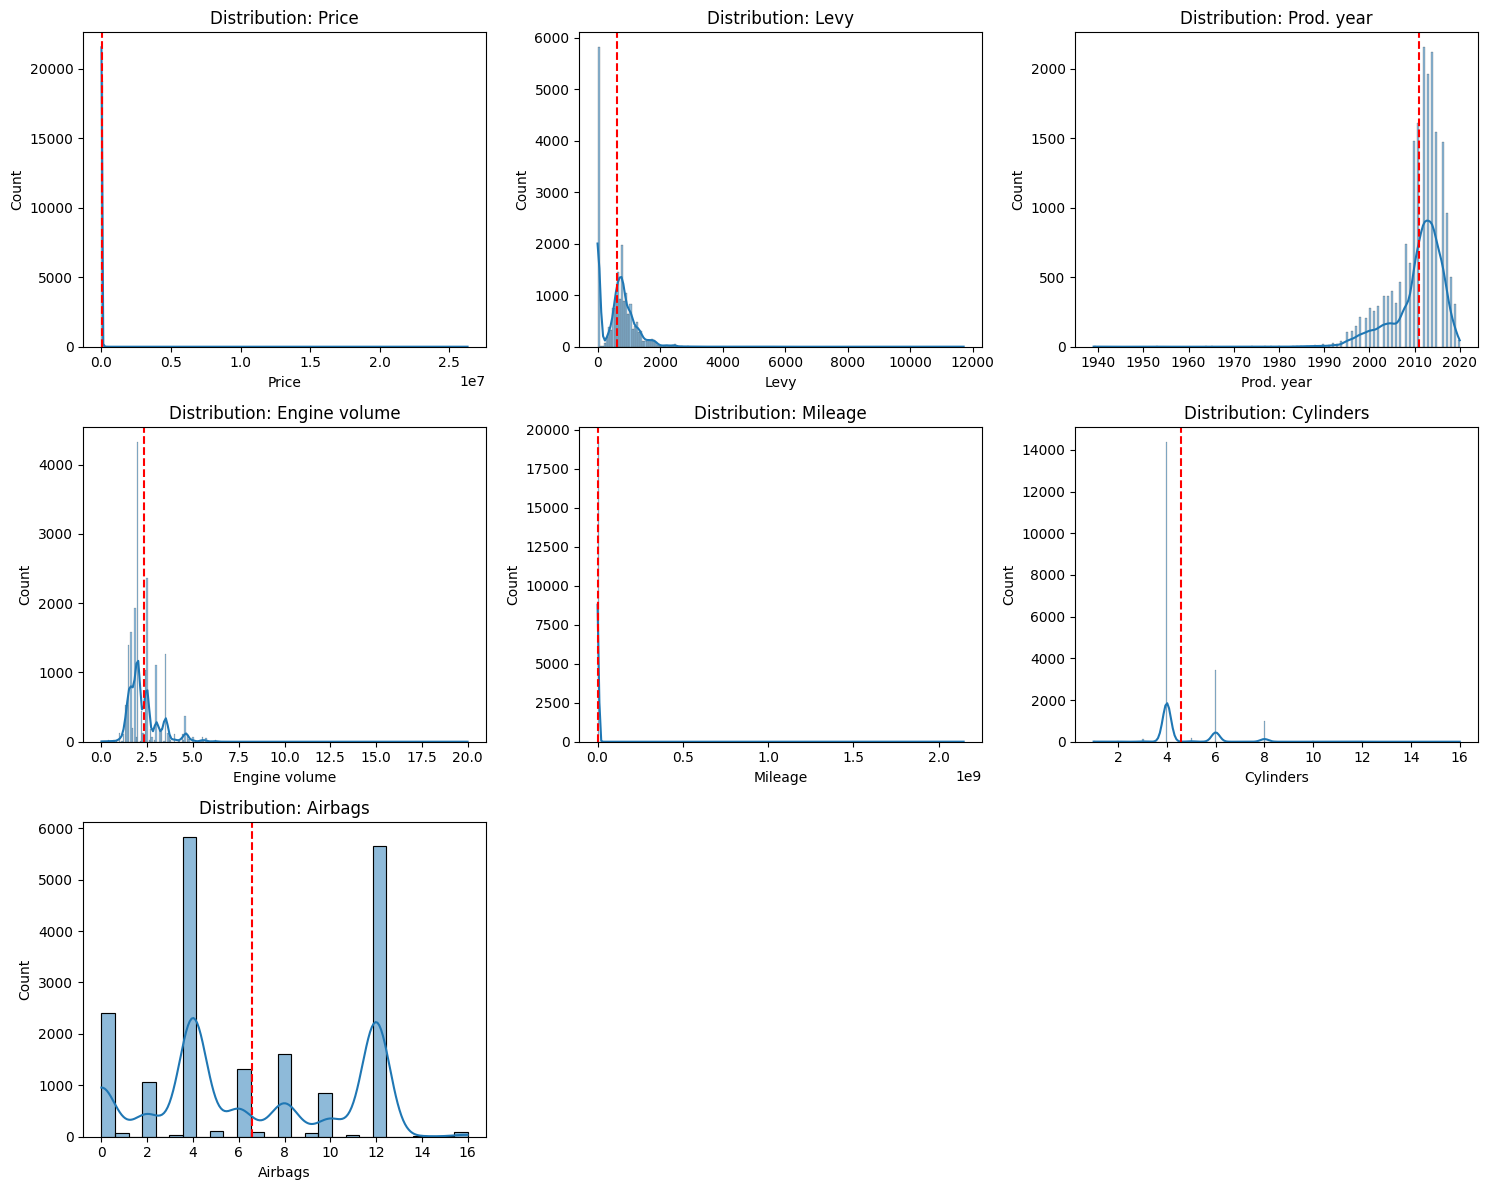

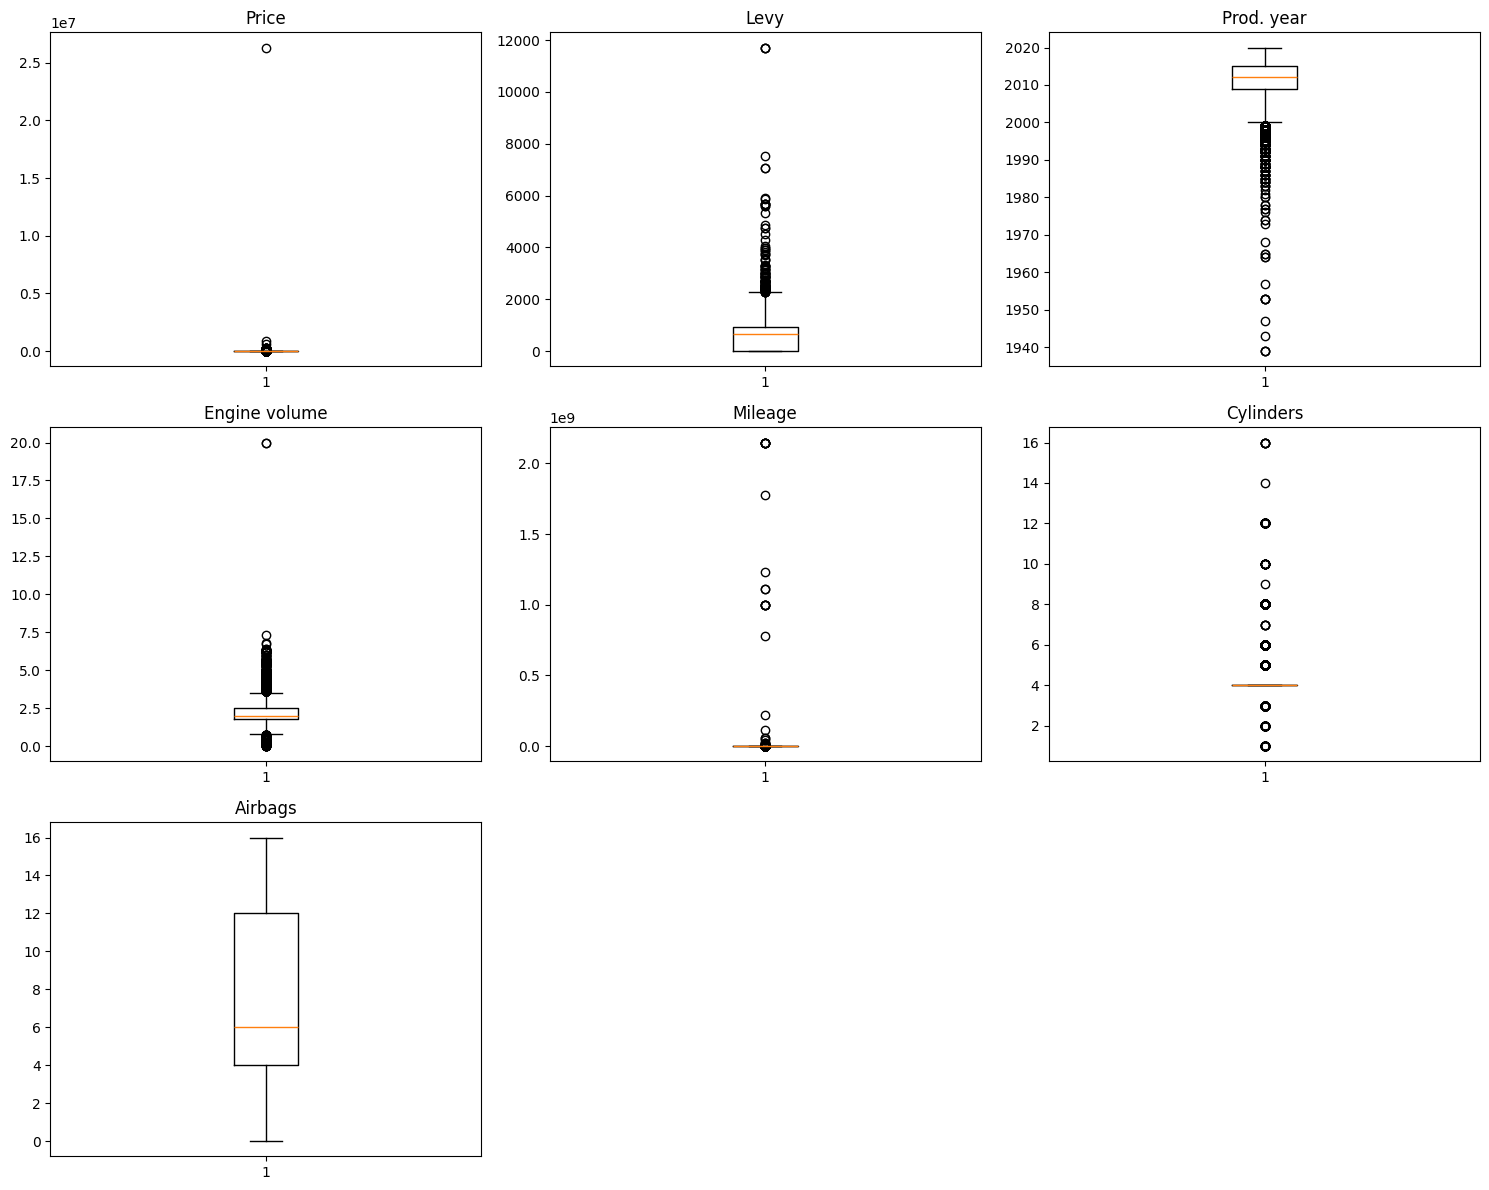

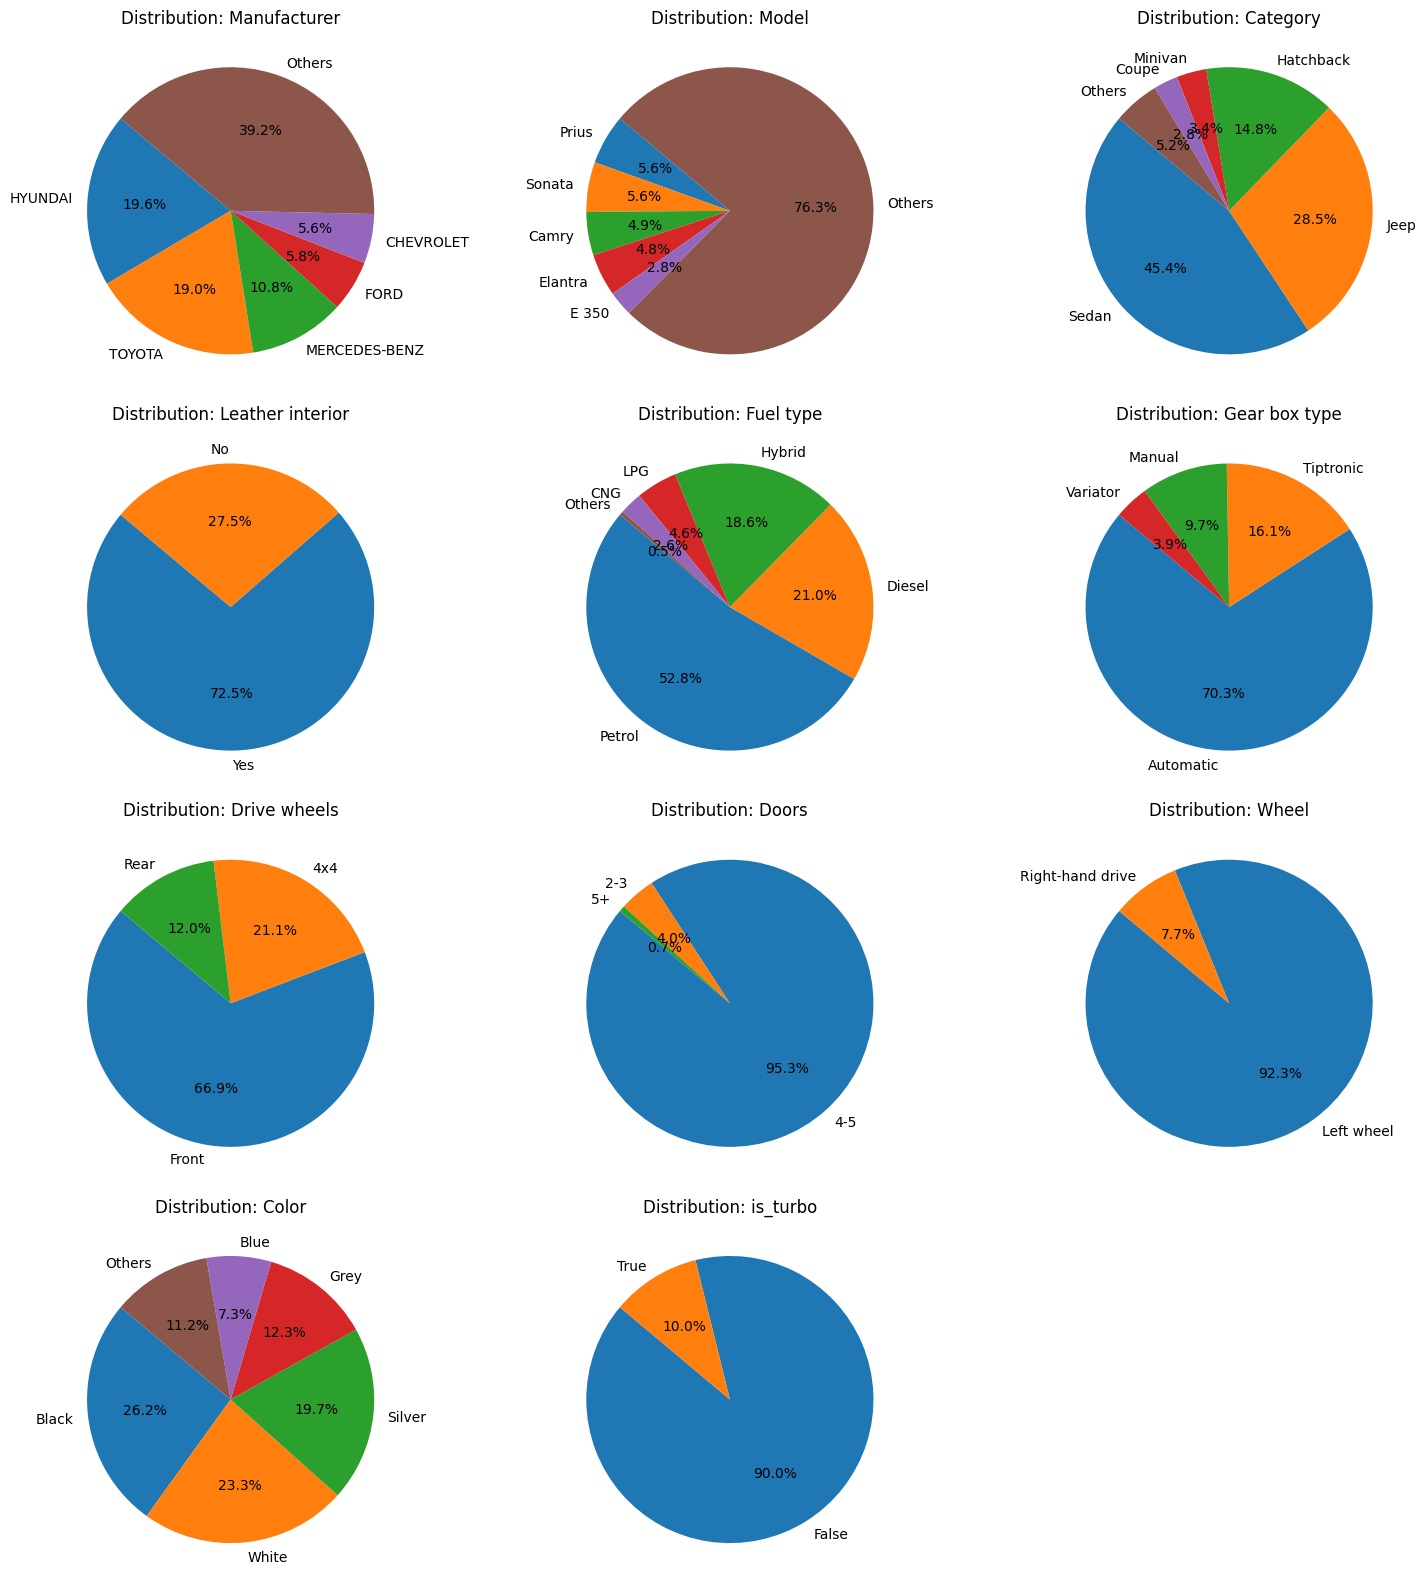


🔹 MULTIVARIATE ANALYSIS


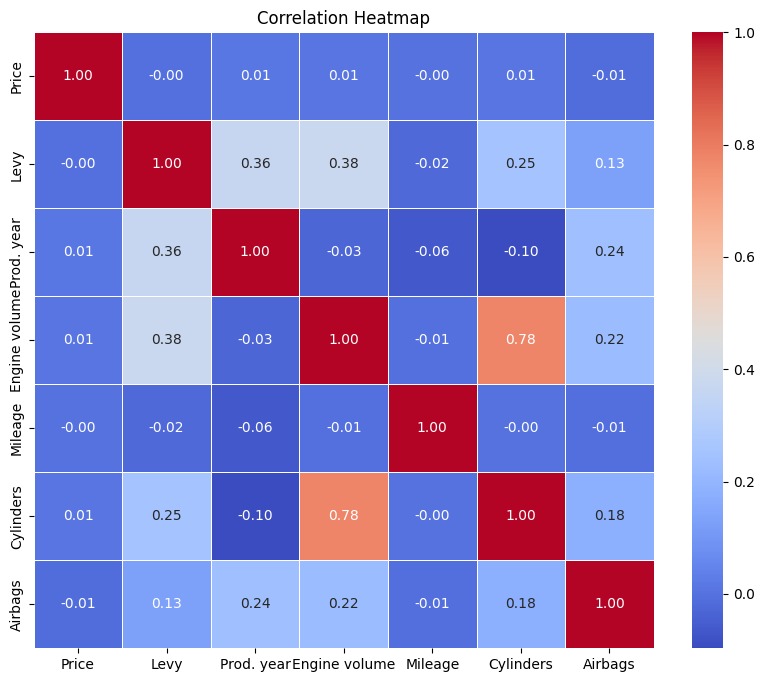

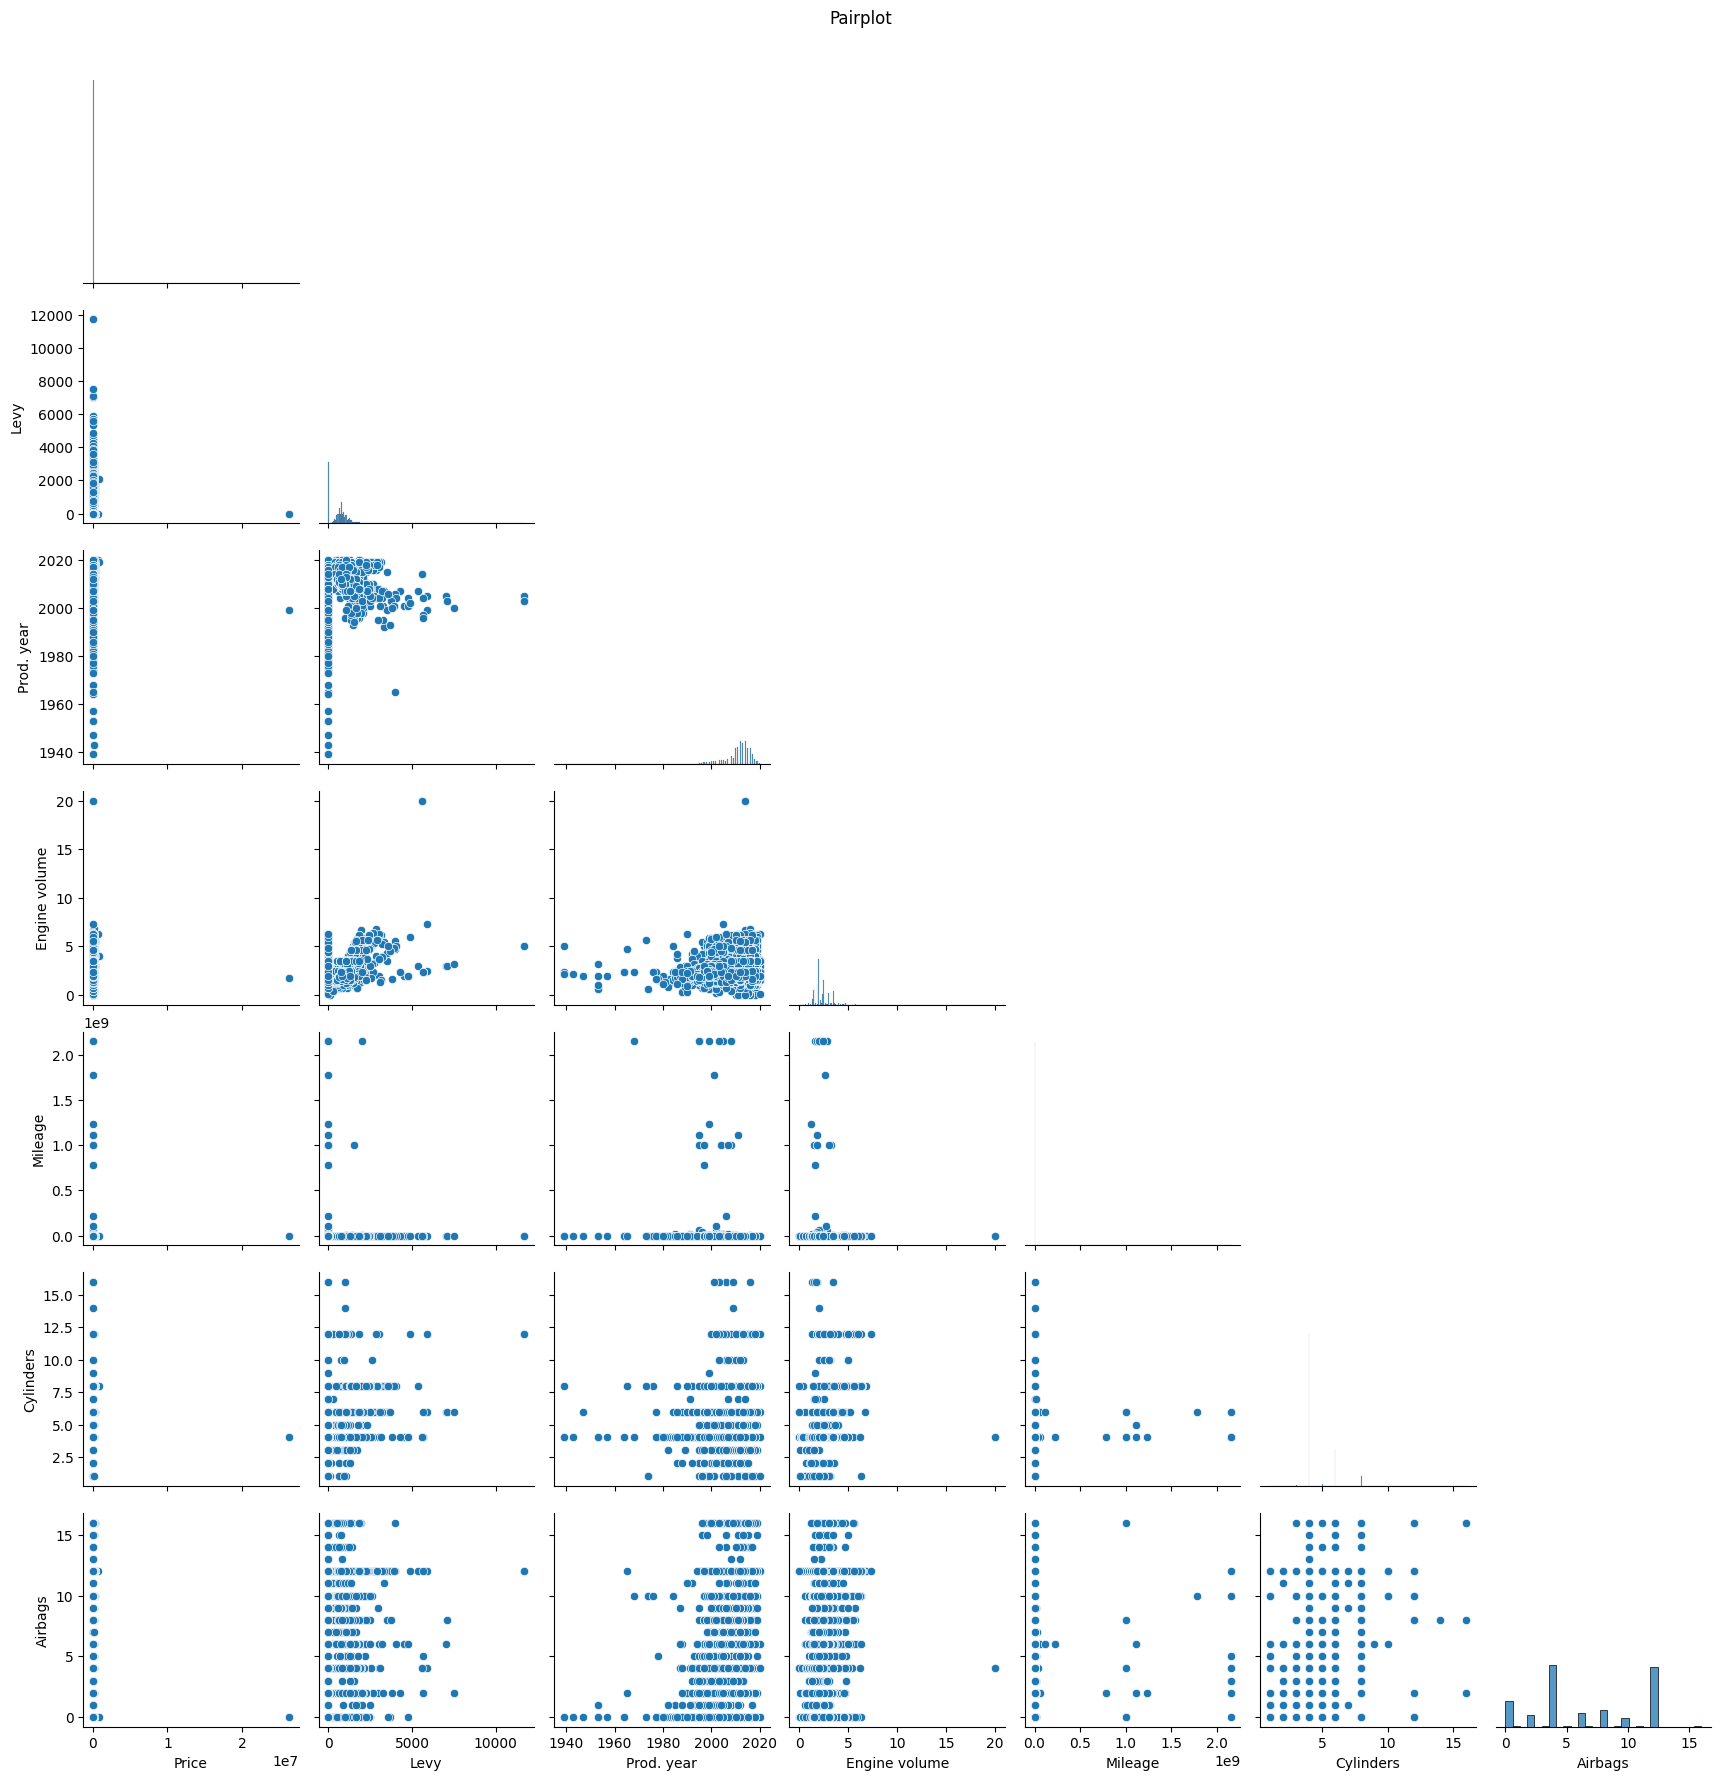

In [8]:
target = "Price"

eda_plots(df_og)

#### Conclusion

##### Univariate Analysis

1. Pie chart
  - Hyundai sells the most cars in this dataset.
  - prius and sonata is the most sold car.
  - sedan is the most sold car category.
  - Most cars have leather interior.
  - Automatic is the most popular gear type.
  - most cards have front drive wheels
  - Doors data is not usable at all because it has
  - most cars have left steering wheel
  - most cars sold are black with white just 3% lower than black cars
  - Patrol is the most popular fuel type in cars.
  - only 10% of the cars have turbo.
2. Box Plot
  - our data has a lot of outliers
  - We have a major noise problem that we will have to fix
  - Car engines didnt have more than 8 liters of volume in 2020 so it's a noise
  - Mileage over a million km is likely error
3. Histplot
  - none of our data is normally distributed

##### Multivariate Analysis

- No feature is really correlated with Price.

### Target Variable Analysis - Price

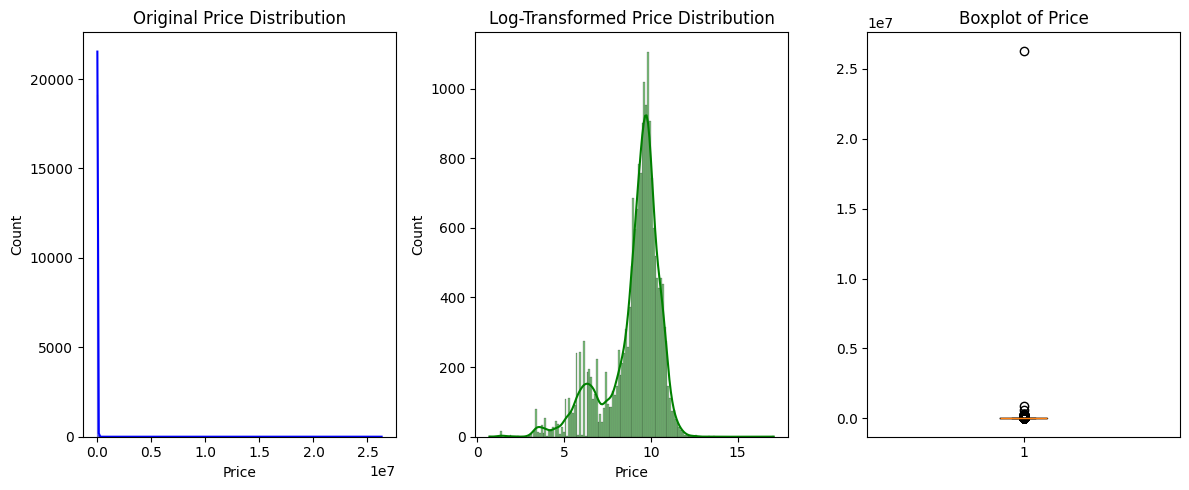

In [9]:
target = "Price"

plt.figure(figsize=(12, 5))

# Plot 1: Standard Distribution
plt.subplot(1, 3, 1)
sns.histplot(df_og[target], kde=True, color='blue')
plt.title(f'Original {target} Distribution')

# Plot 2: Log Transformation
plt.subplot(1, 3, 2)
sns.histplot(np.log1p(df_og[target]), kde=True, color='green')
plt.title(f'Log-Transformed {target} Distribution')

# Plot 3: Boxplot
plt.subplot(1, 3, 3)
plt.boxplot(df_og[target])
plt.title(f"Boxplot of {target}")

plt.tight_layout()
plt.show()

The plots makes things very clear
- Price has extreme outliers that makes it very spiky, so I will log transform it and actually use it as our target.

## Preprocessing

### make a copy of dataframe

In [10]:
df = df_og.copy(deep=True)

### Make the log transformed target

In [11]:
price_upper = df["Price"].quantile(0.99)
df = df[df["Price"] <= price_upper].copy()
df["Price_log"] = np.log1p(df["Price"])

In [12]:
df = df.drop("Price", axis = 1)

target = "Price_log"

In [13]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns
print(f"numerical cols: {numerical_cols}")
print(f"categorical cols: {categorical_cols}")

numerical cols: Index(['Levy', 'Prod. year', 'Engine volume', 'Mileage', 'Cylinders',
       'Airbags', 'Price_log'],
      dtype='str')
categorical cols: Index(['Manufacturer', 'Model', 'Category', 'Leather interior', 'Fuel type',
       'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color', 'is_turbo'],
      dtype='str')


## Feature selection

### VIF for numerical columns

In [14]:
num_cols = df.select_dtypes(include="number").columns
X_num = df[num_cols].drop("Price_log", axis = 1)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_num.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_num.values, i) for i in range(len(X_num.columns))
]
print(vif_data)

         Feature        VIF
0           Levy   2.656189
1     Prod. year  17.272577
2  Engine volume  22.745032
3        Mileage   1.001513
4      Cylinders  40.704733
5        Airbags   3.495056


### Mutual Info Regression for Categorical columns

In [15]:
X_cat = df.select_dtypes(include=["object", "category", "bool"])

oe = OrdinalEncoder()
X_cat_encoded = pd.DataFrame(
    oe.fit_transform(X_cat.astype(str)), columns=X_cat.columns, index=X_cat.index
)

mi_scores = mutual_info_regression(X_cat_encoded, df["Price_log"])

mi_results = pd.DataFrame(
    {"Feature": X_cat.columns, "MI Score": mi_scores}
).sort_values(by="MI Score", ascending=False)

print(mi_results)

             Feature  MI Score
1              Model  0.791149
0       Manufacturer  0.410848
4          Fuel type  0.226429
5      Gear box type  0.189793
2           Category  0.178020
3   Leather interior  0.148000
6       Drive wheels  0.135177
9              Color  0.129076
8              Wheel  0.072385
10          is_turbo  0.049718
7              Doors  0.016084


### Correlation matrix

<Axes: >

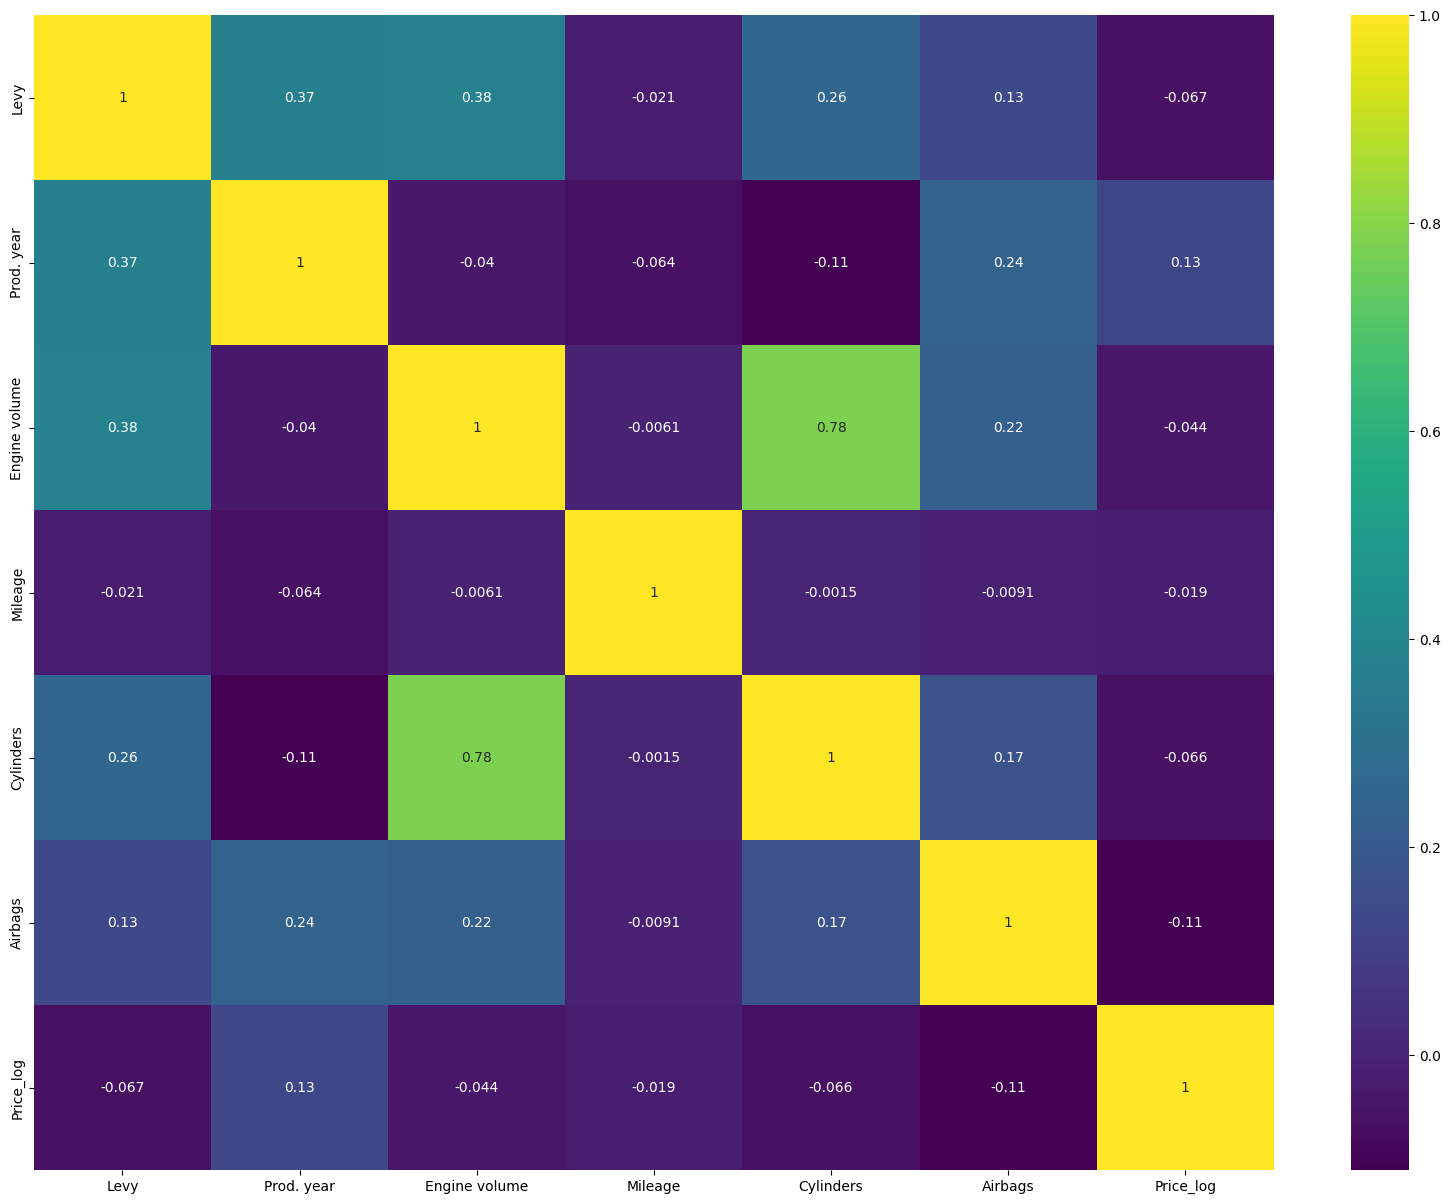

In [16]:
plt.figure(figsize=(20,15))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="viridis")

Now that we have engineered some new columns, we can drop useless columns

In [17]:
X = df.drop(target, axis=1)
y = df[target]

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (19050, 17)
y Shape: (19050,)


## Data splitting

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train Shape: {X_train.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"y_test Shape: {y_test.shape}")

X_train Shape: (15240, 17)
y_train Shape: (15240,)
X_test Shape: (3810, 17)
y_test Shape: (3810,)


## Preprocessors

In [19]:
def add_extra_features(X):
    age = 2026 - X[:, 1]
    mileage_per_year = X[:, 3] / (age + 1)
    engine_cyl_ratio = X[:, 2] / (X[:, 4] + 1)
    X_reduced = X[:, [0, 2, 3, 4, 5]]
    return np.c_[X_reduced, age, mileage_per_year, engine_cyl_ratio]

In [20]:
class OutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self, levy_idx=1, engine_idx=3, mileage_idx=4):
        self.levy_idx = levy_idx
        self.engine_idx = engine_idx
        self.mileage_idx = mileage_idx
        self.levy_cap_ = None

    def fit(self, X, y=None):
        X_arr = np.asarray(X)
        self.levy_cap_ = np.percentile(X_arr[:, self.levy_idx], 99)
        return self

    def transform(self, X):
        X_arr = np.asarray(X).copy()

        X_arr[:, self.levy_idx] = np.clip(
            X_arr[:, self.levy_idx], a_min=None, a_max=self.levy_cap_
        )

        X_arr[:, self.mileage_idx] = np.clip(
            X_arr[:, self.mileage_idx], a_min=None, a_max=999999
        )

        X_arr[:, self.engine_idx] = np.clip(
            X_arr[:, self.engine_idx], a_min=None, a_max=8.0
        )

        return X_arr

In [21]:
# 1. Define feature groups
num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(include="object").columns

# ---------------------------------------------------------
# PIPELINE 1: For Linear/Distance Models (LinReg, SVM, KNN)
# Strategy: StandardScaler + OneHotEncoder
# ---------------------------------------------------------
linear_num_pipeline = Pipeline(
    [
        ("outlier_clipper", OutlierClipper(levy_idx=1, engine_idx=3, mileage_idx=4)),
        ("attribs_adder", FunctionTransformer(add_extra_features)),
        ("std_scaler", StandardScaler()),
    ]
)

linear_preprocessor = ColumnTransformer(
    [
        ("num", linear_num_pipeline, num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ]
)

# ---------------------------------------------------------
# PIPELINE 2: For Tree-Based Models (RF, XGB, LGBM, DT)
# Strategy: No Scaling (Passthrough) + OrdinalEncoder
# ---------------------------------------------------------
tree_num_pipeline = Pipeline(
    [
        ("outlier_clipper", OutlierClipper(levy_idx=1, engine_idx=3, mileage_idx=4)),
        ("attribs_adder", FunctionTransformer(add_extra_features)),
    ]
)

tree_preprocessor = ColumnTransformer(
    [
        ("num", tree_num_pipeline, num_cols),
        (
            "cat",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            cat_cols,
        ),
    ]
)

# ---------------------------------------------------------
# PIPELINE 3: For Neural Networks
# Strategy: MinMaxScaler + OneHotEncoder
# ---------------------------------------------------------
nn_num_pipeline = Pipeline(
    [
        ("outlier_clipper", OutlierClipper(levy_idx=1, engine_idx=3, mileage_idx=4)),
        ("attribs_adder", FunctionTransformer(add_extra_features)),
        ("scaler", MinMaxScaler()),
    ]
)

nn_preprocessor = ColumnTransformer(
    [
        ("num", nn_num_pipeline, num_cols),
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            cat_cols,
        ),
    ]
)

## Model Pipeline

In [22]:
ml_models = {
    "Linear Regression": Pipeline(
        [("pre", linear_preprocessor), ("clf", LinearRegression())]
    ),
    "SVR": Pipeline([("pre", linear_preprocessor), ("clf", SVR())]),
    "KNN": Pipeline([("pre", linear_preprocessor), ("clf", KNeighborsRegressor())]),
    "Decision Tree": Pipeline(
        [("pre", tree_preprocessor), ("clf", DecisionTreeRegressor(random_state=42))]
    ),
    "Random Forest": Pipeline(
        [("pre", tree_preprocessor), ("clf", RandomForestRegressor(random_state=42))]
    ),
    "XGBoost": Pipeline(
        [
            ("pre", tree_preprocessor),
            ("clf", XGBRegressor(device="cuda", random_state=42)),
        ]
    ),
    "LightGBM": Pipeline(
        [
            ("pre", tree_preprocessor),
            ("clf", LGBMRegressor(verbose=-1, random_state=42)),
        ]
    ),
}

## Model training

In [23]:
results_list = []

for name, model in ml_models.items():
    # Train the model on the log-transformed data
    model.fit(X_train, y_train)

    # Model outputs predictions in log scale
    log_pred = model.predict(X_test)

    # Reverse the log transformation for BOTH actuals and predictions
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(log_pred)

    # Calculate metrics on the actual dollar amounts
    rmse = root_mean_squared_error(y_test_real, y_pred_real)
    r2 = r2_score(y_test_real, y_pred_real)

    results_list.append({"Model": name, "RMSE": rmse, "R2": r2})
    print(f"Training done for {name}")

ML_Results = pd.DataFrame(results_list).sort_values(by="R2", ascending=False)
display(ML_Results)

Training done for Linear Regression
Training done for SVR
Training done for KNN
Training done for Decision Tree
Training done for Random Forest
Training done for XGBoost
Training done for LightGBM


,Model,RMSE,R2
4,Random Forest,8568.574463,0.650828
1,SVR,8865.795260,0.626184
6,LightGBM,9214.029208,0.596242
3,Decision Tree,9872.526261,0.536469
2,KNN,9914.793257,0.532492
5,XGBoost,10584.588146,0.467193
0,Linear Regression,13080.750208,0.186257


### Conclusion:
- Random Forest is performing the best here with very low RMSE of 8500 and high R2 of 65% so we will perform hyper parameter tuning.

## Hyperparameter tuning

In [24]:
param_dist = {
    "clf__n_estimators": [100, 300, 500, 800],
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", None],
    "clf__bootstrap": [True, False],
}

rf = Pipeline([("pre", tree_preprocessor), ("clf", RandomForestRegressor())])

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

# Fit the search
print("Starting hyperparameter tuning...")
rf_random.fit(X_train, y_train)

print(f"\nBest Parameters: {rf_random.best_params_}")

best_rf = rf_random.best_estimator_
best_rf

Starting hyperparameter tuning...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best Parameters: {'clf__n_estimators': 800, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_features': 'log2', 'clf__max_depth': 30, 'clf__bootstrap': False}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [25]:
log_pred_rf = best_rf.predict(X_test)

y_test_real = np.expm1(y_test)
y_pred_real_rf = np.expm1(log_pred_rf)

r2_xgb = r2_score(y_test_real, y_pred_real_rf)

rmse_xgb = root_mean_squared_error(y_test_real, y_pred_real_rf)

print("=" * 40)
print(f"Best Random Forest pipeline Score")
print(f"R2 Score: {r2_xgb}")
print(f"RMSE    : {rmse_xgb}")
print("=" * 40)

Best Random Forest pipeline Score
R2 Score: 0.6617700811570977
RMSE    : 8433.249334713819


## Neural Network

In [26]:
X_train_nn = nn_preprocessor.fit_transform(X_train)
X_test_nn = nn_preprocessor.transform(X_test)

input_shape = X_train_nn.shape[1]

In [27]:
# Setup
y_train_arr = np.array(y_train)
input_shape = X_train_nn.shape[1]

optimizers_list = ["Adam", "RMSprop"]
learning_rates = [0.01, 0.001]
batch_sizes = [64, 128]

# Standard KFold for continuous target
kfold = KFold(n_splits=3, shuffle=True, random_state=42)


# Model
def build_model(input_shape, optimizer_name, lr):
    keras.backend.clear_session()

    model = Sequential(
        [
            Dense(
                128,
                activation="relu",
                kernel_initializer="he_normal",
                input_shape=(input_shape,),
            ),
            BatchNormalization(),
            Dropout(0.2),
            Dense(128, activation="relu", kernel_initializer="he_normal"),
            BatchNormalization(),
            Dropout(0.2),
            Dense(64, activation="relu", kernel_initializer="he_normal"),
            BatchNormalization(),
            Dense(32, activation="relu", kernel_initializer="he_normal"),
            Dense(1, activation="linear"),
        ]
    )

    if optimizer_name == "Adam":
        opt = optimizers.Adam(learning_rate=lr)
    else:
        opt = optimizers.RMSprop(learning_rate=lr)

    model.compile(
        loss="mean_squared_error",
        optimizer=opt,
    )
    return model


# Training Loop
cv_results_list = []
print("Starting 3-Fold CV Search for Regression...")
print("-" * 65)

for opt_name in optimizers_list:
    for lr in learning_rates:
        for batch in batch_sizes:
            fold_rmses = []
            config_name = f"{opt_name}_LR{lr}_BS{batch}"

            start_time = time.perf_counter()

            for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train_nn)):
                X_fold_train, X_fold_val = X_train_nn[train_idx], X_train_nn[val_idx]
                y_fold_train, y_fold_val = y_train_arr[train_idx], y_train_arr[val_idx]

                model = build_model(input_shape, opt_name, lr)

                es = EarlyStopping(
                    monitor="val_loss", patience=12, restore_best_weights=True
                )
                rlr = ReduceLROnPlateau(
                    monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6
                )

                model.fit(
                    X_fold_train,
                    y_fold_train,
                    epochs=60,
                    batch_size=batch,
                    validation_data=(X_fold_val, y_fold_val),
                    callbacks=[es, rlr],
                    verbose=0,
                )

                # Predict in log scale
                y_pred_log = model.predict(X_fold_val, verbose=0).flatten()

                # Reverse the log transformation for both actuals and predictions
                y_fold_val_real = np.expm1(y_fold_val)
                y_pred_real = np.expm1(y_pred_log)

                # Calculate real-dollar RMSE
                fold_rmse = root_mean_squared_error(y_fold_val_real, y_pred_real)
                fold_rmses.append(fold_rmse)

            mean_rmse = np.mean(fold_rmses)
            std_rmse = np.std(fold_rmses)

            end_time = time.perf_counter()
            elapsed_time = end_time - start_time

            print(
                f"Config: {config_name:25} | Mean RMSE: ${mean_rmse:,.0f} | StD: ${std_rmse:,.0f} | Time Taken: {elapsed_time:.2f}"
            )

            cv_results_list.append(
                {
                    "Optimizer": opt_name,
                    "LR": lr,
                    "BS": batch,
                    "Mean RMSE": mean_rmse,
                    "StD": std_rmse,
                }
            )

CV_Results = pd.DataFrame(cv_results_list).sort_values(by="Mean RMSE", ascending=True)
print("\n" + "=" * 40)
print("TOP 5 ROBUST CONFIGURATIONS")
print("=" * 40)
display(CV_Results.head(5))

Starting 3-Fold CV Search for Regression...
-----------------------------------------------------------------
Config: Adam_LR0.01_BS64          | Mean RMSE: $10,349 | StD: $186 | Time Taken: 213.96
Config: Adam_LR0.01_BS128         | Mean RMSE: $10,028 | StD: $59 | Time Taken: 124.13
Config: Adam_LR0.001_BS64         | Mean RMSE: $10,657 | StD: $433 | Time Taken: 213.72
Config: Adam_LR0.001_BS128        | Mean RMSE: $10,707 | StD: $468 | Time Taken: 116.59
Config: RMSprop_LR0.01_BS64       | Mean RMSE: $11,670 | StD: $2,455 | Time Taken: 209.98
Config: RMSprop_LR0.01_BS128      | Mean RMSE: $10,288 | StD: $582 | Time Taken: 97.45
Config: RMSprop_LR0.001_BS64      | Mean RMSE: $10,048 | StD: $249 | Time Taken: 214.38
Config: RMSprop_LR0.001_BS128     | Mean RMSE: $10,522 | StD: $212 | Time Taken: 91.39

TOP 5 ROBUST CONFIGURATIONS


,Optimizer,LR,BS,Mean RMSE,StD
1,Adam,0.010,128,10028.270902,58.891168
6,RMSprop,0.001,64,10047.569856,248.620252
5,RMSprop,0.010,128,10287.541473,581.961306
0,Adam,0.010,64,10348.766584,186.084076
7,RMSprop,0.001,128,10521.886795,211.878385


Best Configuration for ANN

- **Optimiser:** Adam
- **Learning Rate:** 0.01
- **Batch Size:** 128


Training Final Model with Adam, LR: 0.01, Batch: 128...
Epoch 1/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.9582 - val_loss: 4.5526 - learning_rate: 0.0100
Epoch 2/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.8499 - val_loss: 1.9363 - learning_rate: 0.0100
Epoch 3/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.7148 - val_loss: 1.6791 - learning_rate: 0.0100
Epoch 4/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.6492 - val_loss: 1.5980 - learning_rate: 0.0100
Epoch 5/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.5489 - val_loss: 1.4283 - learning_rate: 0.0100
Epoch 6/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4699 - val_loss: 1.5021 - learning_rate: 0.0100
Epoch 7/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.4556 - val_loss: 1.4645 - learning_rate: 0.0100
Epoch 8/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4111 - val_loss: 1.4661 - learning_rate: 0.0100
Epoch 9/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3967 - val

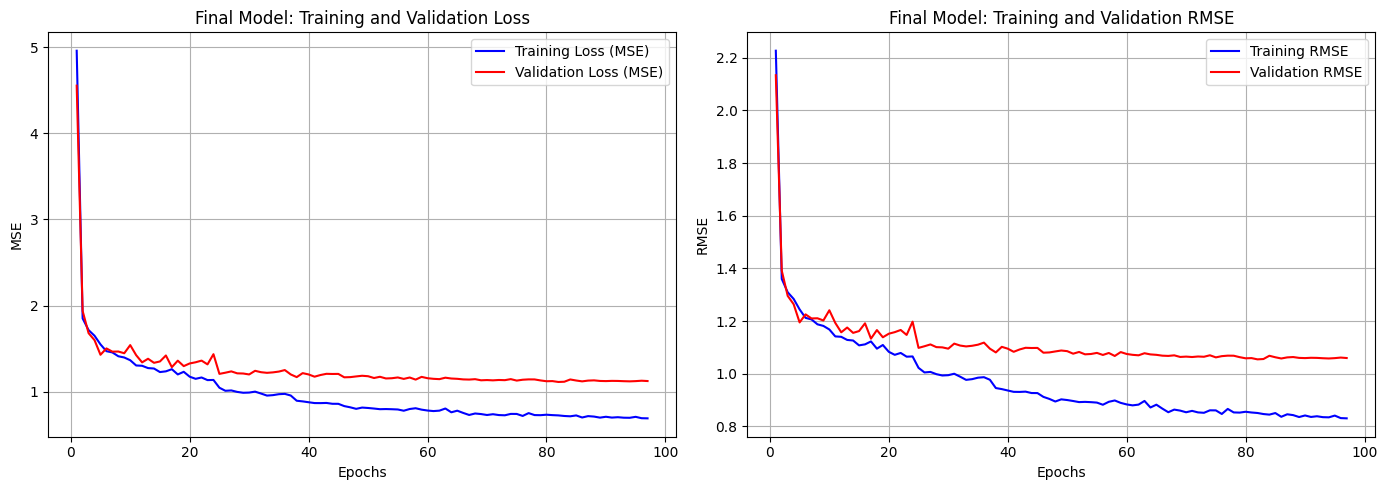

In [28]:
# ---------------------------------------------------------
# 5. EXECUTE FINAL TRAINING
# ---------------------------------------------------------
best_opt = CV_Results.iloc[0]["Optimizer"]
best_lr = CV_Results.iloc[0]["LR"]
best_bs = CV_Results.iloc[0]["BS"]

print(f"\nTraining Final Model with {best_opt}, LR: {best_lr}, Batch: {best_bs}...")

keras.backend.clear_session()
final_model = build_model(input_shape, best_opt, best_lr)

final_callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7, min_lr=1e-7, verbose=1
    ),
]

final_history = final_model.fit(
    X_train_nn,
    y_train_arr,
    validation_split=0.2,
    epochs=150,
    batch_size=int(best_bs),
    callbacks=final_callbacks,
    verbose=1,
)


def plot_final_performance(history):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    # Calculate log-scale RMSE directly from the MSE loss
    rmse = np.sqrt(loss)
    val_rmse = np.sqrt(val_loss)

    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(14, 5))

    # Loss Plot (MSE)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, "b", label="Training Loss (MSE)")
    plt.plot(epochs, val_loss, "r", label="Validation Loss (MSE)")
    plt.title("Final Model: Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)

    # RMSE Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, rmse, "b", label="Training RMSE")
    plt.plot(epochs, val_rmse, "r", label="Validation RMSE")
    plt.title("Final Model: Training and Validation RMSE")
    plt.xlabel("Epochs")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_final_performance(final_history)

In [ ]:
final_model

120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Final Production Regression Metrics ---
Neural Network RMSE: 9444.3798
Neural Network R2:   0.5758


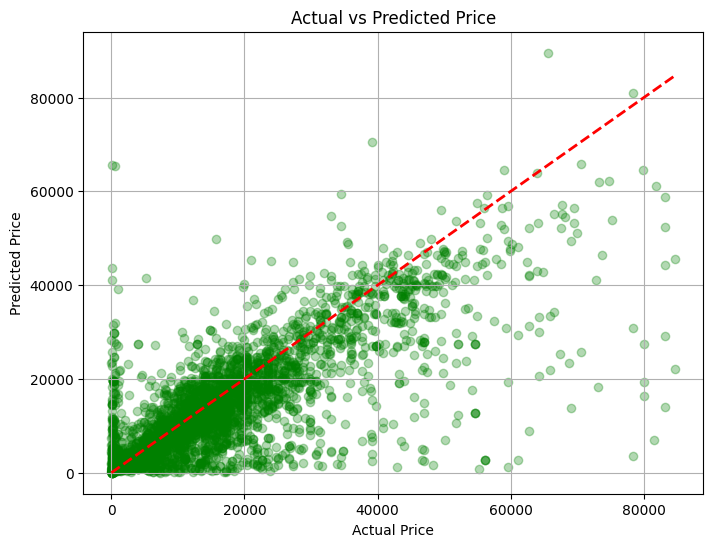

In [29]:
y_pred_nn = final_model.predict(X_test_nn).flatten()

y_test_real = np.expm1(y_test)
y_pred_nn = np.expm1(y_pred_nn)

final_rmse = root_mean_squared_error(y_test_real, y_pred_nn)
final_r2 = r2_score(y_test_real, y_pred_nn)

print("\n--- Final Production Regression Metrics ---")
print(f"Neural Network RMSE: {final_rmse:.4f}")
print(f"Neural Network R2:   {final_r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_real, y_pred_nn, alpha=0.3, color="green")
plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    "r--",
    lw=2,
)
plt.title("Actual vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(True)
plt.show()

## Model Comparison

In [30]:
nn_log_pred = final_model.predict(X_test_nn, verbose=0).flatten()
nn_pred_real = np.expm1(nn_log_pred)

svr_log_pred = ml_models["SVR"].predict(X_test)
svr_pred_real = np.expm1(svr_log_pred)

rf_log_pred = best_rf.predict(X_test)
rf_pred_real = np.expm1(rf_log_pred)

final_results = [
    {
        "Model": "Tuned Random Forest",
        "RMSE ($)": root_mean_squared_error(y_test_real, rf_pred_real),
        "R2 Score": r2_score(y_test_real, rf_pred_real),
    },
    {
        "Model": "Baseline SVR",
        "RMSE ($)": root_mean_squared_error(y_test_real, svr_pred_real),
        "R2 Score": r2_score(y_test_real, svr_pred_real),
    },
    {
        "Model": "Deep Neural Network",
        "RMSE ($)": root_mean_squared_error(y_test_real, nn_pred_real),
        "R2 Score": r2_score(y_test_real, nn_pred_real),
    },
]

Final_Leaderboard = pd.DataFrame(final_results).sort_values(
    by="RMSE ($)", ascending=True
)

print("=" * 50)
print("FINAL TEST SET LEADERBOARD")
print("=" * 50)
display(Final_Leaderboard)

FINAL TEST SET LEADERBOARD


,Model,RMSE ($),R2 Score
0,Tuned Random Forest,8433.249335,0.661770
1,Baseline SVR,8865.795260,0.626184
2,Deep Neural Network,9444.379826,0.575802


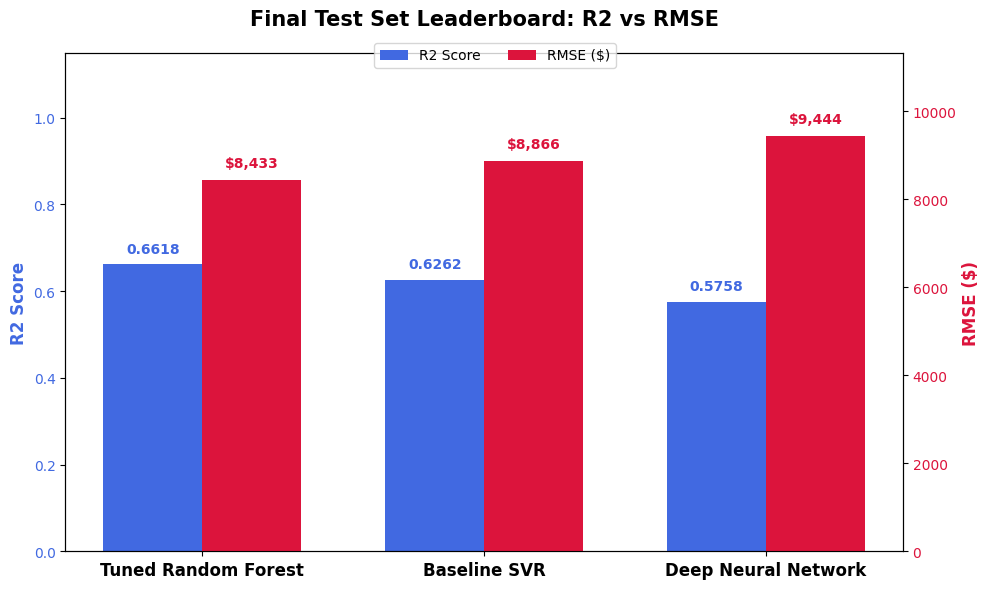

In [31]:
fig, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(Final_Leaderboard["Model"]))
width = 0.35

bars1 = ax1.bar(
    x - width / 2,
    Final_Leaderboard["R2 Score"],
    width,
    label="R2 Score",
    color="royalblue",
)
ax1.set_ylabel("R2 Score", color="royalblue", fontsize=12, fontweight="bold")
ax1.tick_params(axis="y", labelcolor="royalblue")
ax1.set_ylim(0, 1.15)  # Extra headroom for annotations

ax1.set_xticks(x)
ax1.set_xticklabels(Final_Leaderboard["Model"], fontsize=12, fontweight="bold")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + width / 2,
    Final_Leaderboard["RMSE ($)"],
    width,
    label="RMSE ($)",
    color="crimson",
)
ax2.set_ylabel("RMSE ($)", color="crimson", fontsize=12, fontweight="bold")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, Final_Leaderboard["RMSE ($)"].max() * 1.2)

for bar in bars1:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.02,
        f"{yval:.4f}",
        ha="center",
        va="bottom",
        color="royalblue",
        fontweight="bold",
        fontsize=10,
    )

for bar in bars2:
    yval = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (ax2.get_ylim()[1] * 0.02),
        f"${yval:,.0f}",
        ha="center",
        va="bottom",
        color="crimson",
        fontweight="bold",
        fontsize=10,
    )

plt.title(
    "Final Test Set Leaderboard: R2 vs RMSE", fontsize=15, pad=20, fontweight="bold"
)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=2, frameon=True)

plt.tight_layout()
plt.show()

# Conclusion

Neural Network wasn't able to capture more complex data points, and adding more complexity would just increase the inference cost, so we will say that Random Forest is just plain better for this

In [35]:
best_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [36]:
import joblib

model_filename = "car_price_rf_final.joblib"
joblib.dump(best_rf, model_filename, compress=3)

print(f"Success! Model and preprocessor saved as: {model_filename}")

Success! Model and preprocessor saved as: car_price_rf_final.joblib
